# Customer Segmentation & Churn Prediction — RFM Analysis

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Data Loading & Cleaning

In [36]:
df=pd.read_csv("OnlineRetail.csv",encoding="latin1")

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [38]:
df=df.dropna(subset=['CustomerID'])

## 2. RFM Feature Engineering

In [39]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
last_purchase = df.groupby('CustomerID')['InvoiceDate'].max()
latest_date = df['InvoiceDate'].max()
Recency = (latest_date - last_purchase).dt.days
print(Recency.head())

CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
Name: InvoiceDate, dtype: int64


In [40]:
Frequency=df.groupby('CustomerID')['InvoiceNo'].nunique()

In [41]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']

In [42]:
Monetary=df.groupby('CustomerID')['TotalPrice'].sum()

In [43]:
rfm=pd.concat([Recency, Frequency, Monetary], axis=1)
rfm.columns=['Recency', 'Frequency','Monetary']
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          2      0.00
12347.0           1          7   4310.00
12348.0          74          4   1797.24
12349.0          18          1   1757.55
12350.0         309          1    334.40


In [44]:
df[df['CustomerID']==12346]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.6


## 3. Data Quality Investigation

In [45]:
rfm=rfm[rfm['Monetary']>0]

In [46]:
rfm.shape

(4322, 3)

## 4. Customer Segmentation KMeans Clustering

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

In [48]:
scalar=StandardScaler()
rfm_scaled=scalar.fit_transform(rfm[['Recency','Frequency','Monetary']])

In [49]:
inertia_values=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(rfm_scaled)
    inertia=kmeans.inertia_
    inertia_values.append(inertia)
print(inertia_values)

[9322.880477756371, 5518.628476260023, 4808.592168321806, 3180.4235485726776, 2719.2833413053463, 1891.9893299686562, 1583.3588461197362, 1420.2181211909208, 1331.2416127404838]


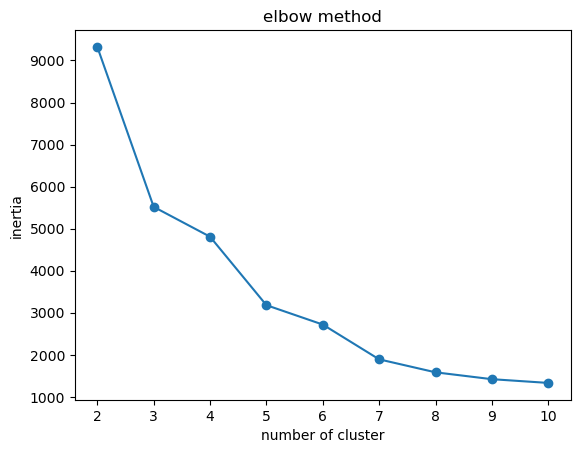

In [50]:
plt.plot(range(2,11), inertia_values, marker='o')
plt.title('elbow method')
plt.xlabel('number of cluster')
plt.ylabel('inertia')
plt.show()

In [51]:
kmeans_finals=KMeans(n_clusters=5,random_state=42)
clusters=kmeans_finals.fit_predict(rfm_scaled)

In [52]:
rfm['Cluster'] = clusters

In [53]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,1,7,4310.00,1
12348.0,74,4,1797.24,1
12349.0,18,1,1757.55,1
12350.0,309,1,334.40,0
12352.0,35,11,1545.41,1


In [54]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,243.889831,1.838041,485.190255
1,40.222258,4.773597,1468.887938
2,0.333333,213.666667,67328.500000
3,8.355932,36.889831,19205.043644
4,2.666667,64.666667,241136.560000


## 5. Cluster Interpretation (Champions Investigation)

In [55]:
cluster2_customers = rfm[rfm['Cluster'] == 2].index

In [56]:
cluster2_orders = df[df['CustomerID'].isin(cluster2_customers)]
print(cluster2_orders['Quantity'].mean())

6.7063363557858375


In [57]:
print(cluster2_orders['Quantity'].max())
print(cluster2_orders['Quantity'].describe())

640
count    18528.000000
mean         6.706336
std         18.306497
min       -288.000000
25%          1.000000
50%          2.000000
75%          6.000000
max        640.000000
Name: Quantity, dtype: float64


In [58]:
cluster2_orders[cluster2_orders['Quantity'] >100].shape[0]

88

## 6. Churn Prediction Model

In [59]:
rfm['Churn']=rfm['Recency'].apply(lambda x:1 if x>180 else 0)

In [60]:
print(rfm['Churn'].value_counts())

Churn
0    3491
1     831
Name: count, dtype: int64


In [61]:
x=rfm.drop(columns=['Churn','Recency'])
y=rfm['Churn']

In [62]:
num_cols=['Frequency','Monetary']
cat_cols=['Cluster']
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [63]:
preprocessor=ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer',SimpleImputer(strategy='median')),
        ('scalar',StandardScaler())
    ]),num_cols),
    ('cat',Pipeline([
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder())
    ]),cat_cols)
])
model_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(class_weight='balanced',random_state=42))
])
model_pipeline.fit(x_train,y_train)
y_pred=model_pipeline.predict(x_test)

In [64]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       699
           1       0.77      0.79      0.78       166

    accuracy                           0.91       865
   macro avg       0.86      0.87      0.86       865
weighted avg       0.92      0.91      0.91       865



## 7. Model Saving & Deployment

In [65]:
import joblib
joblib.dump(model_pipeline, 'churn_model.pkl')

['churn_model.pkl']

In [66]:
loaded_model=joblib.load('churn_model.pkl')